# GFDL regional biases: forced-ocean parameterization comparison

Regional bias diagnostics for GFDL's 4 forced-ocean experiments, extending
`gfdl_horizontal_biases.ipynb`'s global maps with a set of boundary-current
and basin-scale regions, mirroring CESM's `regional_biases.ipynb`. Uses the
same `*_thetao_time_mean.nc`/`*_so_time_mean.nc` bias fields (from
`mom6_tools.TS_levels`, unmodified) -- no new computation, just a different
regional summary of data already in `data/gfdl_1988_2012/`.

Since GFDL's own grid is regular 1x1 degree (unlike CESM's tripolar grid),
region masks and maps use the clean 1D `xh`/`yh` axes directly rather than
2D `geolon`/`geolat` fields or a cartopy projection -- simpler, and immune
to the geolon-wrap rendering bug documented in `gfdl_horizontal_biases.ipynb`.

RMSE bar charts show all 4 experiments (CTRL, bANN, uANN, bANN_uANN)
side by side per region -- one panel, since GFDL has no coupled/forced
split the way CESM's version does.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from mom6_tools.m6plot import myStats

from experiment import Experiment

%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 16})

REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
GFDL_DIR = os.path.join(REPO, 'data', 'gfdl_1988_2012')

print('REPO     =', REPO)
print('GFDL_DIR =', GFDL_DIR)

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


Basemap module not found. Some regional plots may not function properly


REPO     = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
GFDL_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/gfdl_1988_2012


In [2]:
experiment_defs = [
    ('gfdl_CTRL',       GFDL_DIR),
    ('gfdl_bANN',       GFDL_DIR),
    ('gfdl_uANN',       GFDL_DIR),
    ('gfdl_bANN_uANN',  GFDL_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

names = list(exps.keys())
CTRL = 'gfdl_CTRL'

LABELS = {
    'gfdl_CTRL':      'CTRL',
    'gfdl_bANN':      'bANN',
    'gfdl_uANN':      'uANN',
    'gfdl_bANN_uANN': 'bANN_uANN',
}
COLORS = {
    'gfdl_CTRL':      'k',
    'gfdl_bANN':      '#0072B2',
    'gfdl_uANN':      '#E69F00',
    'gfdl_bANN_uANN': '#009E73',
}

print('Initialized:', names)

[gfdl_CTRL] casename=gfdl_CTRL, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format/run


MOM6 grid successfully loaded... 



[gfdl_bANN] casename=gfdl_bANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_uANN] casename=gfdl_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_bANN_uANN] casename=gfdl_bANN_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format/run
MOM6 grid successfully loaded... 

Initialized: ['gfdl_CTRL', 'gfdl_bANN', 'gfdl_uANN', 'gfdl_bANN_uANN']


# 1. Analysis regions

Rectangular lon/lat boxes (0-360 convention), identical to CESM's
`regional_biases.ipynb`:

| Region | Latitude | Longitude |
|---|---|---|
| Global | everything | everything |
| Southern Ocean | 30S-60S | all |
| Agulhas | 30S-60S | 0-60E |
| Malvinas | 30S-60S | 60W-0 |
| Kuroshio | 20N-50N | 120E-180 |
| Gulf Stream | 30N-60N | 80W-20W |
| Tropical Pacific | 30S-30N | 130E-70W |

In [3]:
REGIONS = {
    'Global':           None,
    'Southern Ocean':   (-60, -30,   0, 360),
    'Agulhas':          (-60, -30,   0,  60),
    'Malvinas':         (-60, -30, 300, 360),
    'Kuroshio':         ( 20,  50, 120, 180),
    'Gulf Stream':      ( 30,  60, 280, 340),
    'Tropical Pacific': (-30,  30, 130, 290),
}
REGION_COLORS = {
    'Southern Ocean':   'k',
    'Agulhas':          'tab:green',
    'Malvinas':         'tab:purple',
    'Kuroshio':         'tab:orange',
    'Gulf Stream':      'tab:red',
    'Tropical Pacific': 'tab:cyan',
}
REGION_NAMES = list(REGIONS.keys())


def region_mask(exp, region):
    """Boolean DataArray (yh, xh) selecting grid cells inside `region`.
    GFDL's grid is regular 1x1deg, so xh/yh ARE longitude/latitude exactly
    -- no need for 2D geolon/geolat or wrap handling."""
    if REGIONS[region] is None:                 # Global -> everything (ocean cells)
        return exp.grd.wet > 0
    s, n, w, e = REGIONS[region]
    lat = exp.grd.yh
    lon360 = exp.grd.xh % 360.0
    return (lat >= s) & (lat <= n) & (lon360 >= w) & (lon360 <= e) & (exp.grd.wet > 0)


def bias_map(get_bias, title, vmin, vmax, cbar_label):
    """Bias map for CTRL with every analysis region outlined -- one
    reference map showing where each region sits, not one per experiment."""
    exp = exps[CTRL]
    bias = get_bias(exp).where(exp.grd.wet > 0)
    fig, ax = plt.subplots(figsize=(13, 6), dpi=120)
    ax.set_facecolor('gray')
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(exp.grd.xh.values, exp.grd.yh.values,
                       np.ma.masked_invalid(bias.values),
                       cmap='RdBu_r', norm=norm, shading='auto')
    cb = fig.colorbar(pc, ax=ax, shrink=0.85, extend='both')
    cb.set_label(cbar_label)
    for name, box in REGIONS.items():
        if box is None:
            continue
        s, n, w, e = box
        color = REGION_COLORS[name]
        rect = plt.Rectangle((w, s), e - w, n - s, linewidth=2.0,
                             edgecolor=color, facecolor='none', zorder=5)
        ax.add_patch(rect)
        ax.text(0.5 * (w + e), 0.5 * (s + n), name, color=color, fontsize=10,
               fontweight='bold', ha='center', va='center',
               bbox=dict(boxstyle='round', fc='white', ec=color, alpha=0.85), zorder=6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def region_rmse(exp, region, bias):
    """Area-weighted RMSE of a (yh, xh) bias field over `region`."""
    m = region_mask(exp, region) & np.isfinite(bias)
    area = np.ma.masked_invalid(exp.area.where(m).values)
    bias_masked = np.ma.masked_invalid(bias.where(m).values)
    _, _, _, _, rmse = myStats(bias_masked, area)
    return rmse


def plot_rmse_bars(get_bias, title, unit):
    """Grouped bar chart: one group per region, one bar per experiment."""
    biases = {name: get_bias(exps[name]) for name in names}
    rmse = pd.DataFrame(
        {name: [region_rmse(exps[name], r, biases[name]) for r in REGION_NAMES]
         for name in names},
        index=REGION_NAMES,
    )
    print(f'Area-weighted RMSE ({unit}):')
    display(rmse.round(3))

    x = np.arange(len(REGION_NAMES))
    width = 0.2
    fig, ax = plt.subplots(figsize=(14, 5), dpi=120)
    for k, name in enumerate(names):
        ax.bar(x + (k - 1.5) * width, rmse[name].values, width,
              label=LABELS[name], color=COLORS[name])
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(REGION_NAMES, rotation=30, ha='right')
    ax.set_ylabel(f'RMSE ({unit})')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# 2. SST bias and regions

Surface temperature bias (CTRL $-$ WOA18) with every analysis region outlined.

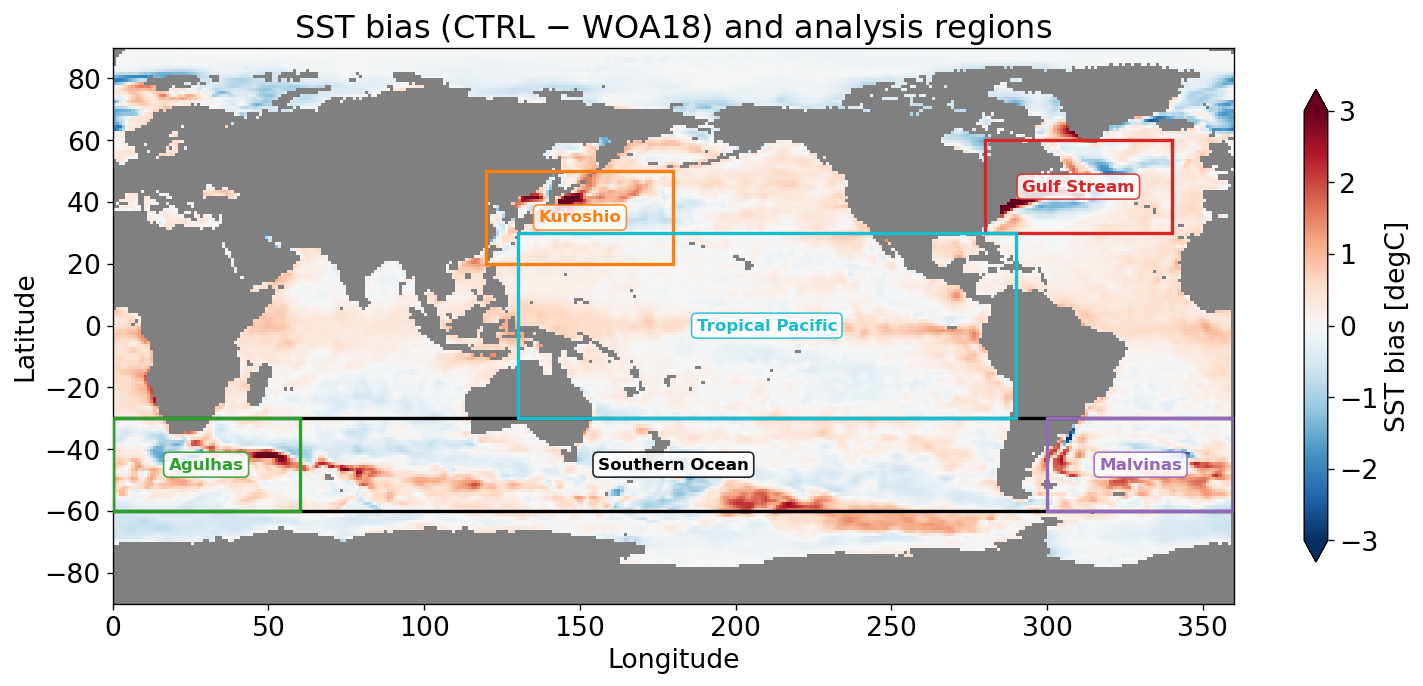

In [4]:
bias_map(lambda e: e.thetao().thetao_bias.isel(z_l=0),
         'SST bias (CTRL $-$ WOA18) and analysis regions', -3, 3, 'SST bias [degC]')

# 3. SST bias RMSE by region

Area-weighted RMSE (model $-$ WOA18) of surface temperature over each region, all 4 experiments.

Area-weighted RMSE (degC):


,gfdl_CTRL,gfdl_bANN,gfdl_uANN,gfdl_bANN_uANN
Global,0.498,0.547,0.493,0.496
Southern Ocean,0.590,0.607,0.675,0.670
Agulhas,0.751,0.763,0.780,0.780
Malvinas,0.751,0.742,1.044,1.018
Kuroshio,0.747,1.005,0.597,0.787
Gulf Stream,1.094,1.416,0.742,0.750
Tropical Pacific,0.288,0.280,0.260,0.259


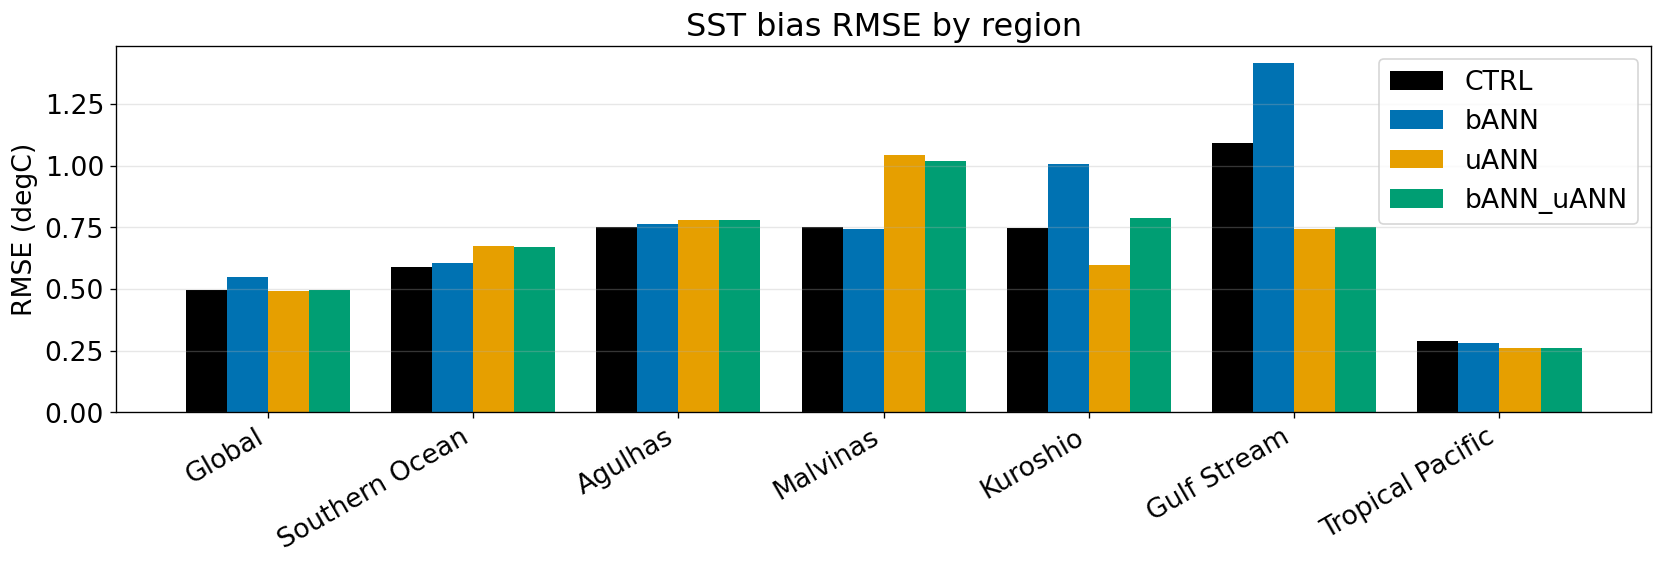

In [5]:
plot_rmse_bars(lambda e: e.thetao().thetao_bias.isel(z_l=0),
              'SST bias RMSE by region', 'degC')

# 4. SSS bias and regions

Sea-surface salinity bias (CTRL $-$ WOA18) with every analysis region outlined.

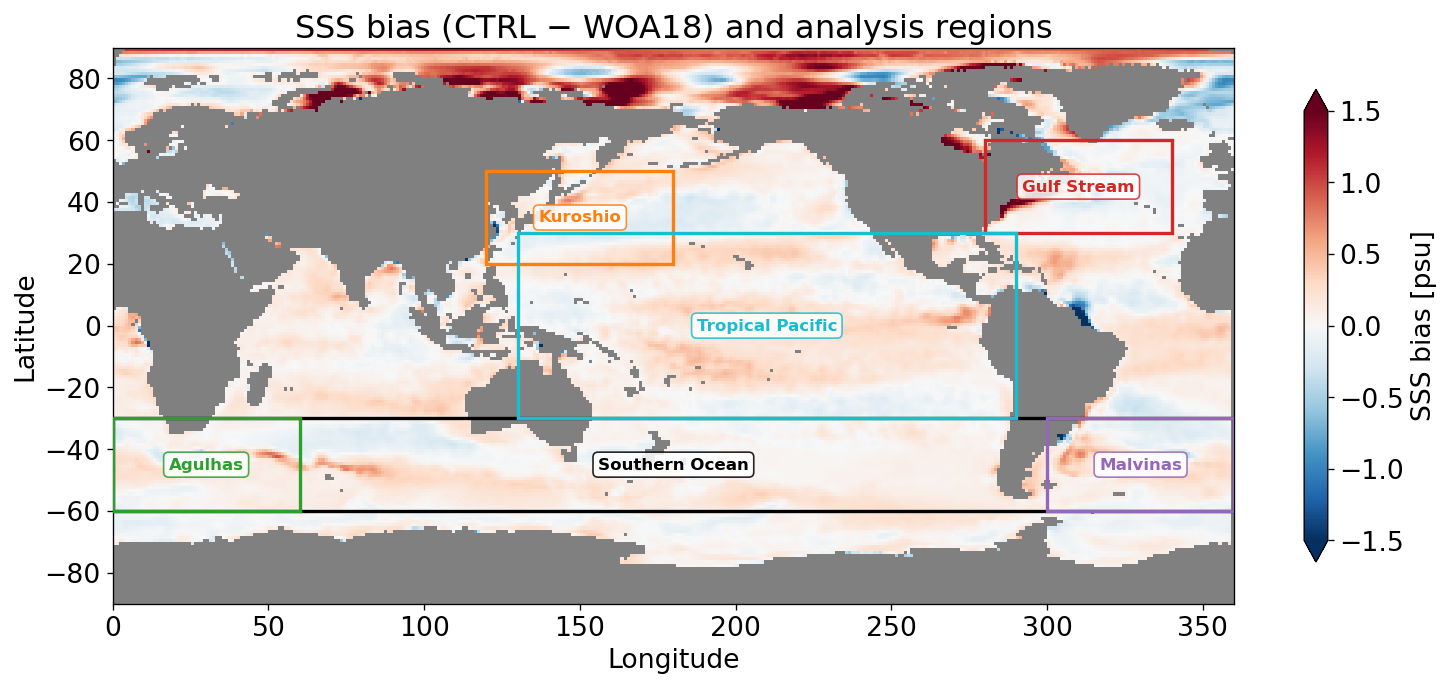

In [6]:
bias_map(lambda e: e.so().so_bias.isel(z_l=0),
         'SSS bias (CTRL $-$ WOA18) and analysis regions', -1.5, 1.5, 'SSS bias [psu]')

# 5. SSS bias RMSE by region

Area-weighted RMSE (model $-$ WOA18) of sea-surface salinity over each region, all 4 experiments.

Area-weighted RMSE (psu):


,gfdl_CTRL,gfdl_bANN,gfdl_uANN,gfdl_bANN_uANN
Global,0.371,0.355,0.371,0.347
Southern Ocean,0.170,0.163,0.220,0.208
Agulhas,0.156,0.145,0.186,0.178
Malvinas,0.259,0.262,0.357,0.360
Kuroshio,0.215,0.205,0.195,0.198
Gulf Stream,0.389,0.425,0.233,0.250
Tropical Pacific,0.190,0.175,0.194,0.174


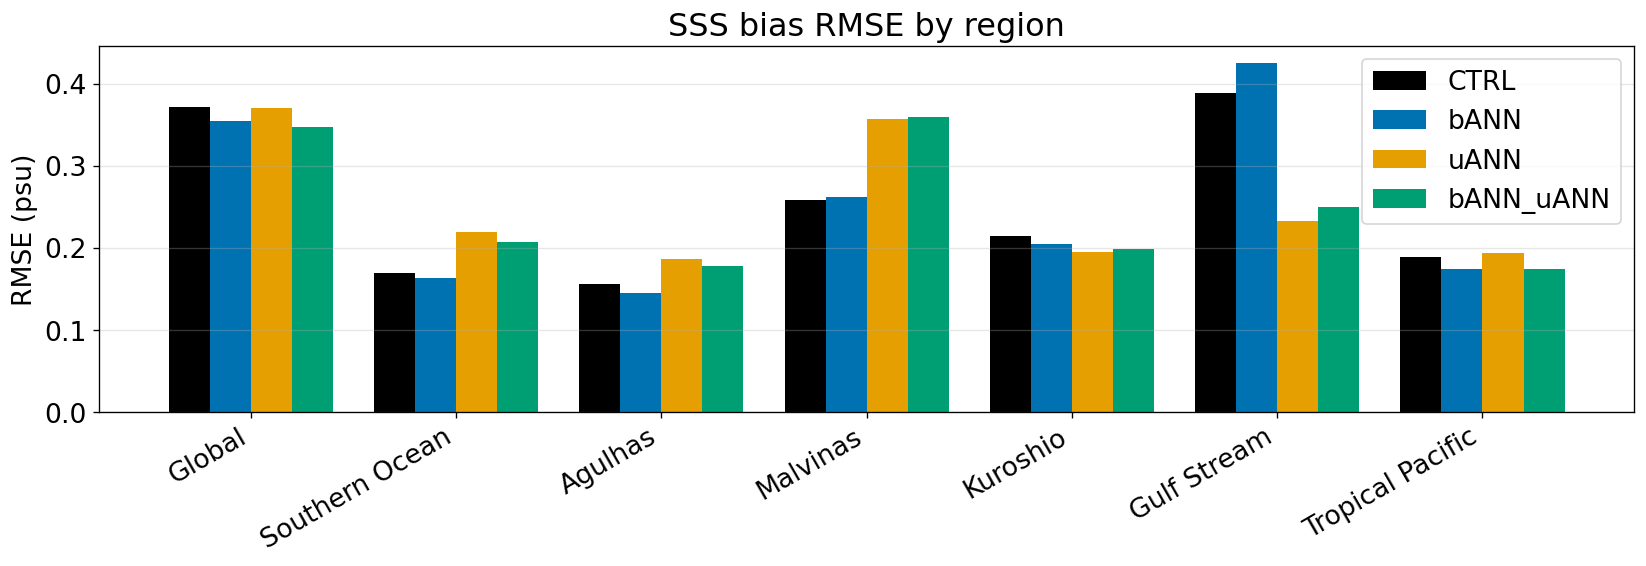

In [7]:
plot_rmse_bars(lambda e: e.so().so_bias.isel(z_l=0),
              'SSS bias RMSE by region', 'psu')

# 6. Temperature bias at 250 m and regions

Temperature bias (CTRL $-$ WOA18) at the level nearest 250 m.

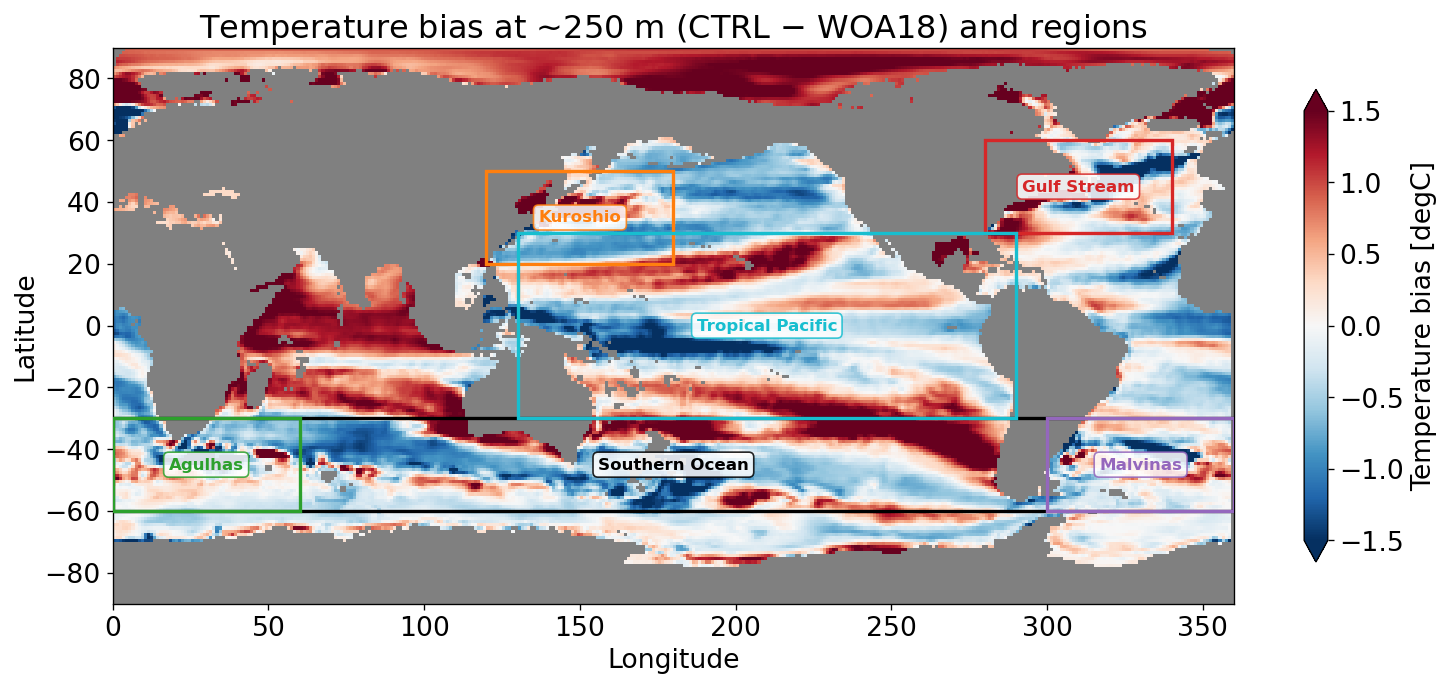

In [8]:
TARGET_DEPTH = 250.0
bias_map(lambda e: e.thetao().thetao_bias.sel(z_l=TARGET_DEPTH, method='nearest'),
         'Temperature bias at ~250 m (CTRL $-$ WOA18) and regions', -1.5, 1.5, 'Temperature bias [degC]')

# 7. Temperature bias RMSE at 250 m by region

Area-weighted RMSE (model $-$ WOA18) at ~250 m over each region, all 4 experiments.

Area-weighted RMSE (degC):


,gfdl_CTRL,gfdl_bANN,gfdl_uANN,gfdl_bANN_uANN
Global,0.899,0.915,0.988,0.957
Southern Ocean,0.987,0.883,1.104,0.985
Agulhas,0.837,0.797,0.926,0.813
Malvinas,0.875,0.817,1.885,1.587
Kuroshio,1.084,1.486,0.737,1.053
Gulf Stream,1.490,1.969,1.044,0.937
Tropical Pacific,0.795,0.865,0.869,0.987


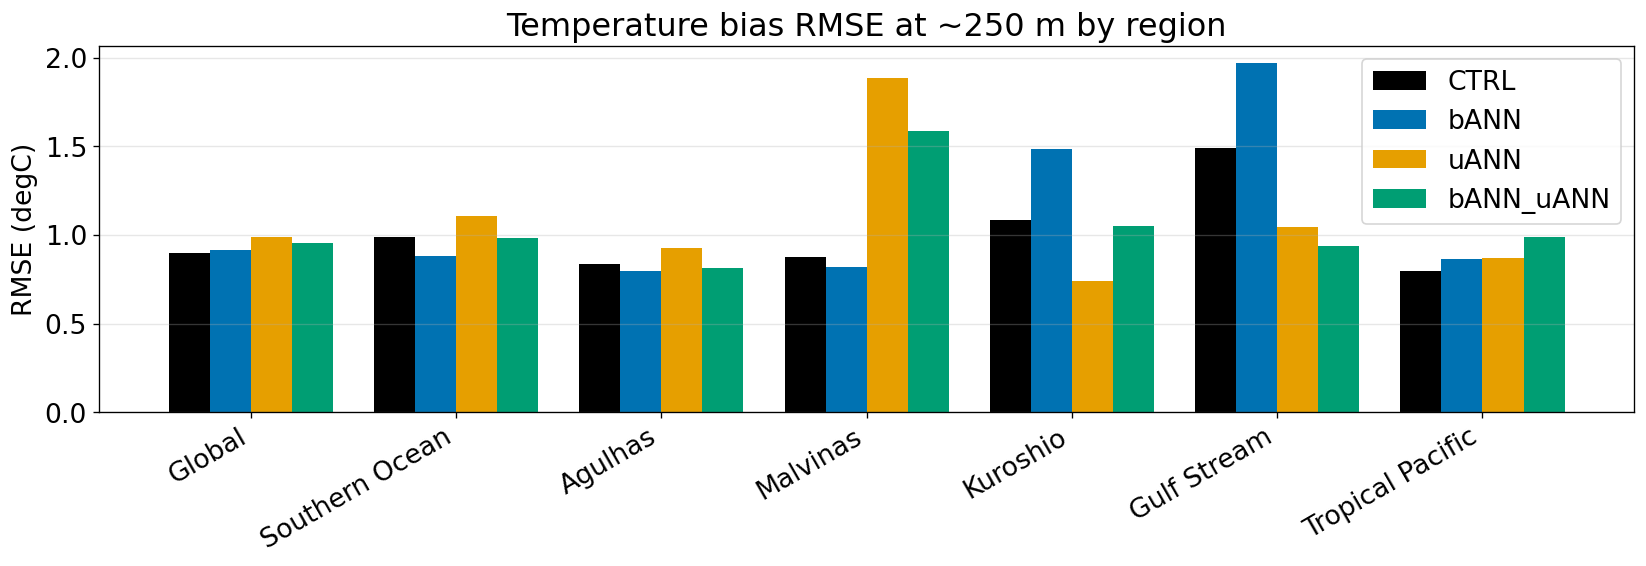

In [9]:
plot_rmse_bars(lambda e: e.thetao().thetao_bias.sel(z_l=TARGET_DEPTH, method='nearest'),
              'Temperature bias RMSE at ~250 m by region', 'degC')

# 8. Salinity bias at 250 m and regions

Salinity bias (CTRL $-$ WOA18) at the level nearest 250 m.

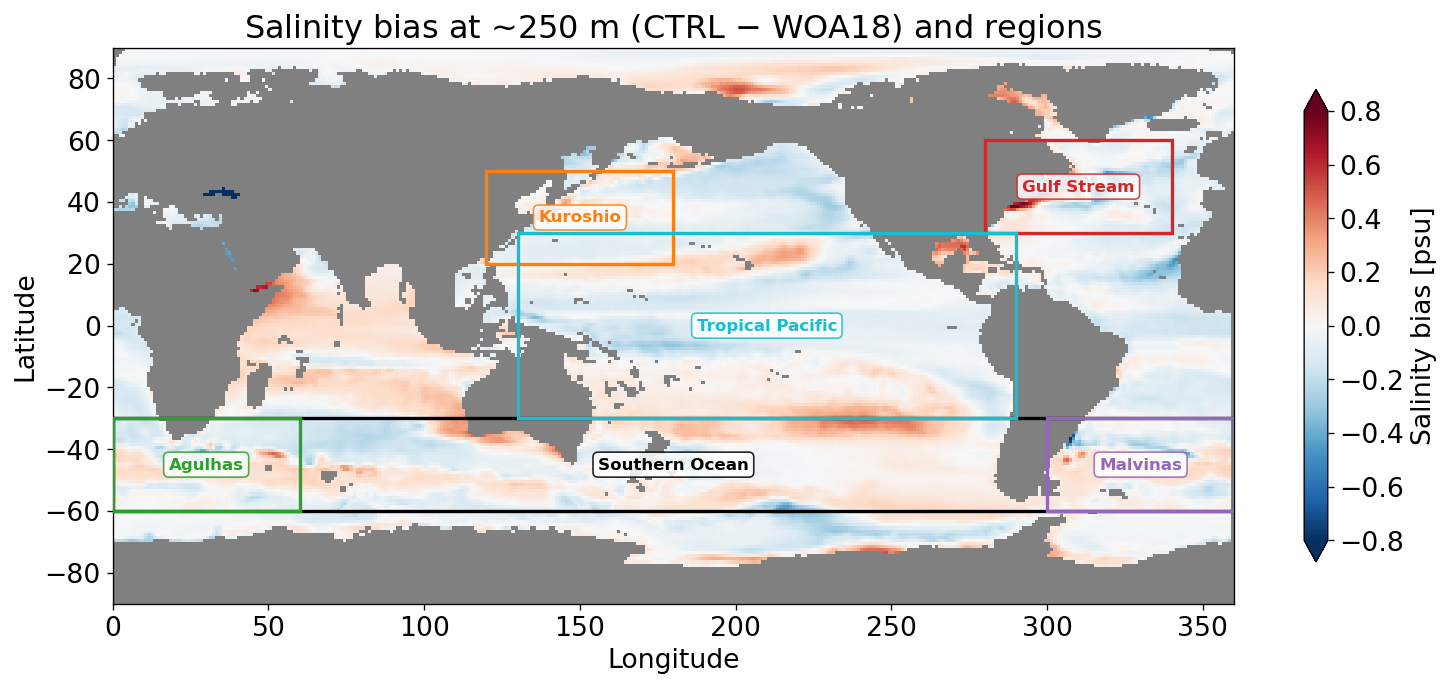

In [10]:
bias_map(lambda e: e.so().so_bias.sel(z_l=TARGET_DEPTH, method='nearest'),
         'Salinity bias at ~250 m (CTRL $-$ WOA18) and regions', -0.8, 0.8, 'Salinity bias [psu]')

# 9. Salinity bias RMSE at 250 m by region

Area-weighted RMSE (model $-$ WOA18) at ~250 m over each region, all 4 experiments.

Area-weighted RMSE (psu):


,gfdl_CTRL,gfdl_bANN,gfdl_uANN,gfdl_bANN_uANN
Global,0.127,0.116,0.140,0.128
Southern Ocean,0.131,0.114,0.171,0.151
Agulhas,0.115,0.108,0.135,0.127
Malvinas,0.120,0.111,0.265,0.241
Kuroshio,0.089,0.101,0.070,0.103
Gulf Stream,0.192,0.201,0.127,0.119
Tropical Pacific,0.108,0.102,0.106,0.104


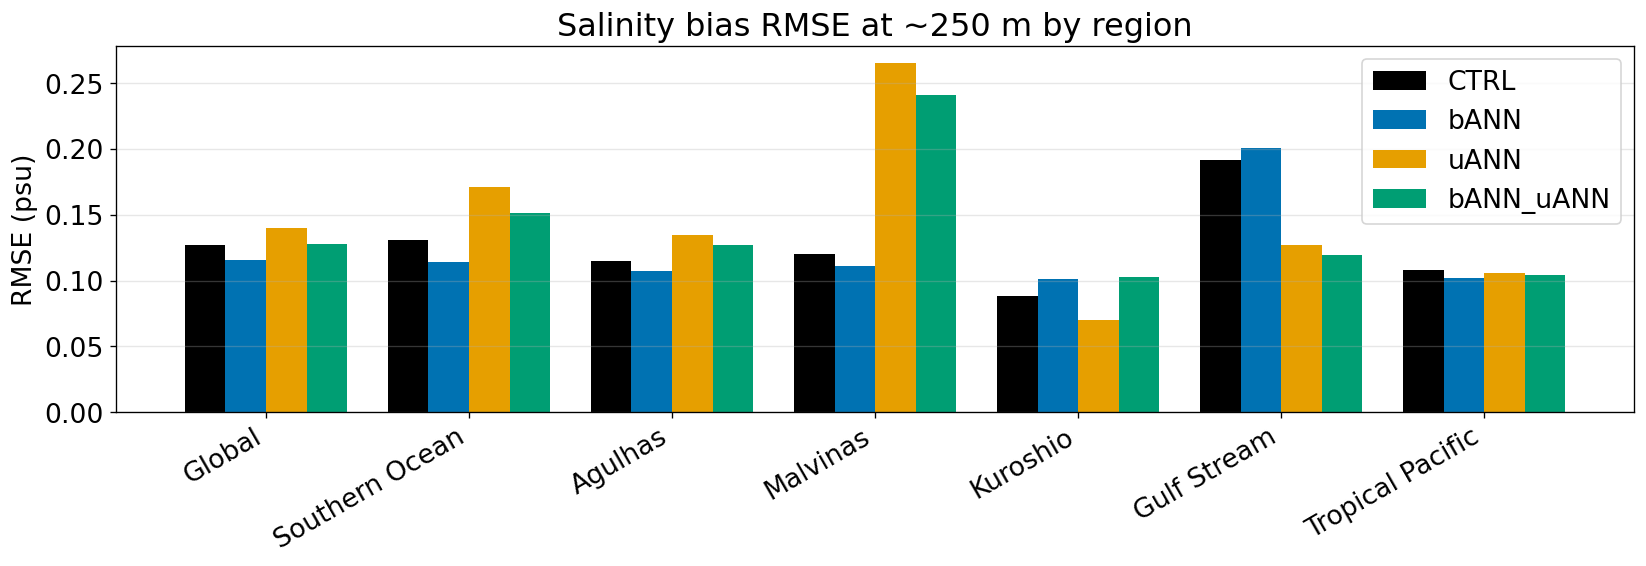

In [11]:
plot_rmse_bars(lambda e: e.so().so_bias.sel(z_l=TARGET_DEPTH, method='nearest'),
              'Salinity bias RMSE at ~250 m by region', 'psu')